## Generate image montage per top feature

In [1]:
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(grid))
suppressPackageStartupMessages(library(patchwork))
suppressPackageStartupMessages(library(RColorBrewer))

## Define load image function

Referenced from [pyroptosis_signature_data_analysis repo](https://github.com/WayScience/pyroptosis_signature_data_analysis/blob/main/figures/3.figure3/notebooks/3.assemble_montage.ipynb).

In [2]:
load_image <- function(path){
    img <- png::readPNG(path)
    # Convert the image to a raster object
    g <- grid::rasterGrob(img, interpolate=TRUE)

    # Create a ggplot
    p <- ggplot() +
    annotation_custom(g, xmin=-Inf, xmax=Inf, ymin=-Inf, ymax=Inf) +
    theme_void()
    return(p)
}

In [3]:
# Directory with single-cell crops
sc_crop_dir <- "./sc_crops"

# Path to each composite image (min or max) per top feature
## Top coefficient feature for Null
max_top_feat1 <- file.path(sc_crop_dir, "max_Null_feature_1", "max_Null_feature_1_composite_cropped.png")
max_top_feat2 <- file.path(sc_crop_dir, "max_Null_feature_2", "max_Null_feature_2_composite_cropped.png")
max_top_feat3 <- file.path(sc_crop_dir, "max_Null_feature_3", "max_Null_feature_3_composite_cropped.png")
max_top_feat4 <- file.path(sc_crop_dir, "max_Null_feature_4", "max_Null_feature_4_composite_cropped.png")
max_top_feat5 <- file.path(sc_crop_dir, "max_Null_feature_5", "max_Null_feature_5_composite_cropped.png")
max_top_feat6 <- file.path(sc_crop_dir, "max_Null_feature_6", "max_Null_feature_6_composite_cropped.png")
min_top_feat1 <- file.path(sc_crop_dir, "min_Null_feature_1", "min_Null_feature_1_composite_cropped.png")
min_top_feat2 <- file.path(sc_crop_dir, "min_Null_feature_2", "min_Null_feature_2_composite_cropped.png")
min_top_feat3 <- file.path(sc_crop_dir, "min_Null_feature_3", "min_Null_feature_3_composite_cropped.png")
min_top_feat4 <- file.path(sc_crop_dir, "min_Null_feature_4", "min_Null_feature_4_composite_cropped.png")
min_top_feat5 <- file.path(sc_crop_dir, "min_Null_feature_5", "min_Null_feature_5_composite_cropped.png")
min_top_feat6 <- file.path(sc_crop_dir, "min_Null_feature_6", "min_Null_feature_6_composite_cropped.png")

In [4]:
# load top coefficient feat images 
max_top_feat1_image <- load_image(max_top_feat1)
max_top_feat2_image <- load_image(max_top_feat2)
max_top_feat3_image <- load_image(max_top_feat3)
max_top_feat4_image <- load_image(max_top_feat4)
max_top_feat5_image <- load_image(max_top_feat5)
max_top_feat6_image <- load_image(max_top_feat6)
min_top_feat1_image <- load_image(min_top_feat1)
min_top_feat2_image <- load_image(min_top_feat2)
min_top_feat3_image <- load_image(min_top_feat3)
min_top_feat4_image <- load_image(min_top_feat4)
min_top_feat5_image <- load_image(min_top_feat5)
min_top_feat6_image <- load_image(min_top_feat6)

# Create list of images
list_of_images <- list(
    max_top_feat1_image,
    max_top_feat2_image,
    max_top_feat3_image,
    max_top_feat4_image,
    max_top_feat5_image,
    max_top_feat6_image,
    min_top_feat1_image,
    min_top_feat2_image,
    min_top_feat3_image,
    min_top_feat4_image,
    min_top_feat5_image,
    min_top_feat6_image
)

In [5]:
width <- 2.5
height <- 2.5

text_size <- 13

options(repr.plot.width = width, repr.plot.height = height)

# blank
blank <- (
    ggplot()
    + geom_text(aes(x = 0.5, y = 0.5, label = ""), size = text_size) 
    + theme_void()
)

# ggplot of just text for labelling y axis
WT_text <- (
    ggplot()
    + geom_text(aes(x = 0.5, y = 0.5, label = "WT A3 (NF1 +/+) genotype\nrepresentative single cells"), size = text_size, angle = 90) 
    + theme_void()
)
Null_text <- (
    ggplot()
    + geom_text(aes(x = 0.5, y = 0.5, label = "Null C04 (NF1 -/-) genotype\nrepresentative single cells"), size = text_size, angle = 90) 
    + theme_void()
)

In [6]:
# stich the images together for each top feature
## Top coefficient feature
max_top_feat_images_1 <- (
    list_of_images[[1]]
    + list_of_images[[2]]
    + list_of_images[[3]]
    + plot_layout(nrow = 1, widths = c(0.5, 0.5, 0.5))
)
max_top_feat_images_2 <- (
    list_of_images[[4]]
    + list_of_images[[5]]
    + list_of_images[[6]]
    + plot_layout(nrow = 1, widths = c(0.5, 0.5, 0.5))
)
min_top_feat_images_1 <- (
    list_of_images[[7]]
    + list_of_images[[8]]
    + list_of_images[[9]]
    + plot_layout(nrow = 1, widths = c(0.5, 0.5, 0.5))
)
min_top_feat_images_2 <- (
    list_of_images[[10]]
    + list_of_images[[11]]
    + list_of_images[[12]]
    + plot_layout(nrow = 1, widths = c(0.5, 0.5, 0.5))
)

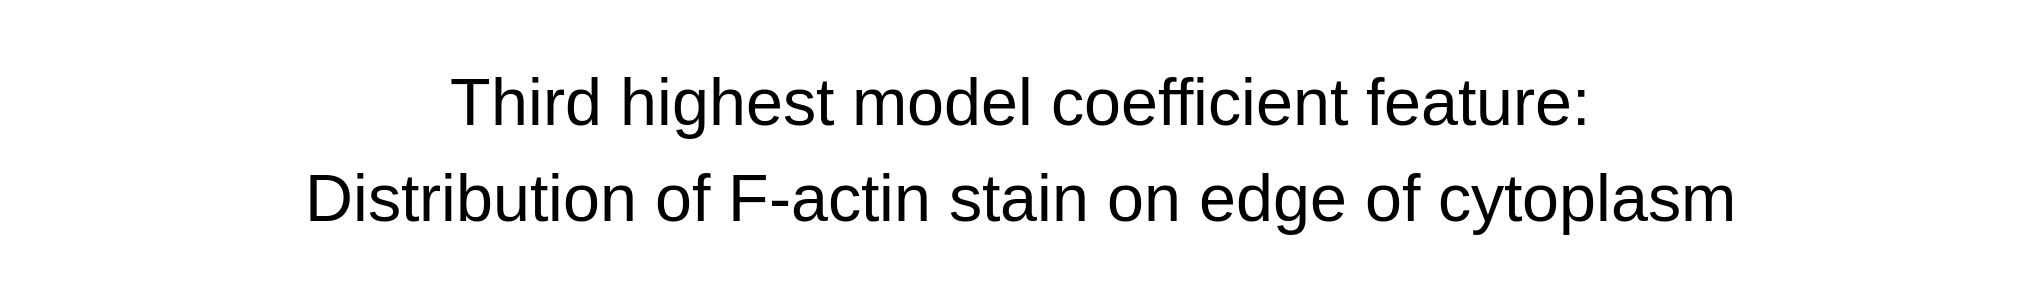

In [7]:
# Generate labels for each plot with CellProfiler feature
width <- 2.5
height <- 2.5

text_size <- 14

options(repr.plot.width = width, repr.plot.height = height)

# ggplot of just text
top_feat_text <- (
    ggplot()
    + geom_text(aes(x = 0.5, y = 0.5, label = "Third highest model coefficient feature:\nDistribution of F-actin stain on edge of cytoplasm"), size = text_size) 
    + theme_void()
)

# patch feature texts together
top_patch_text <- (
    top_feat_text
    + plot_layout(nrow = 1)
)

width <- 17
height <- 2.5

options(repr.plot.width = width, repr.plot.height = height)

top_patch_text


## Generate top coefficient feature image montages

### Distribution of F-actin staining on edge of cytoplasm compartment

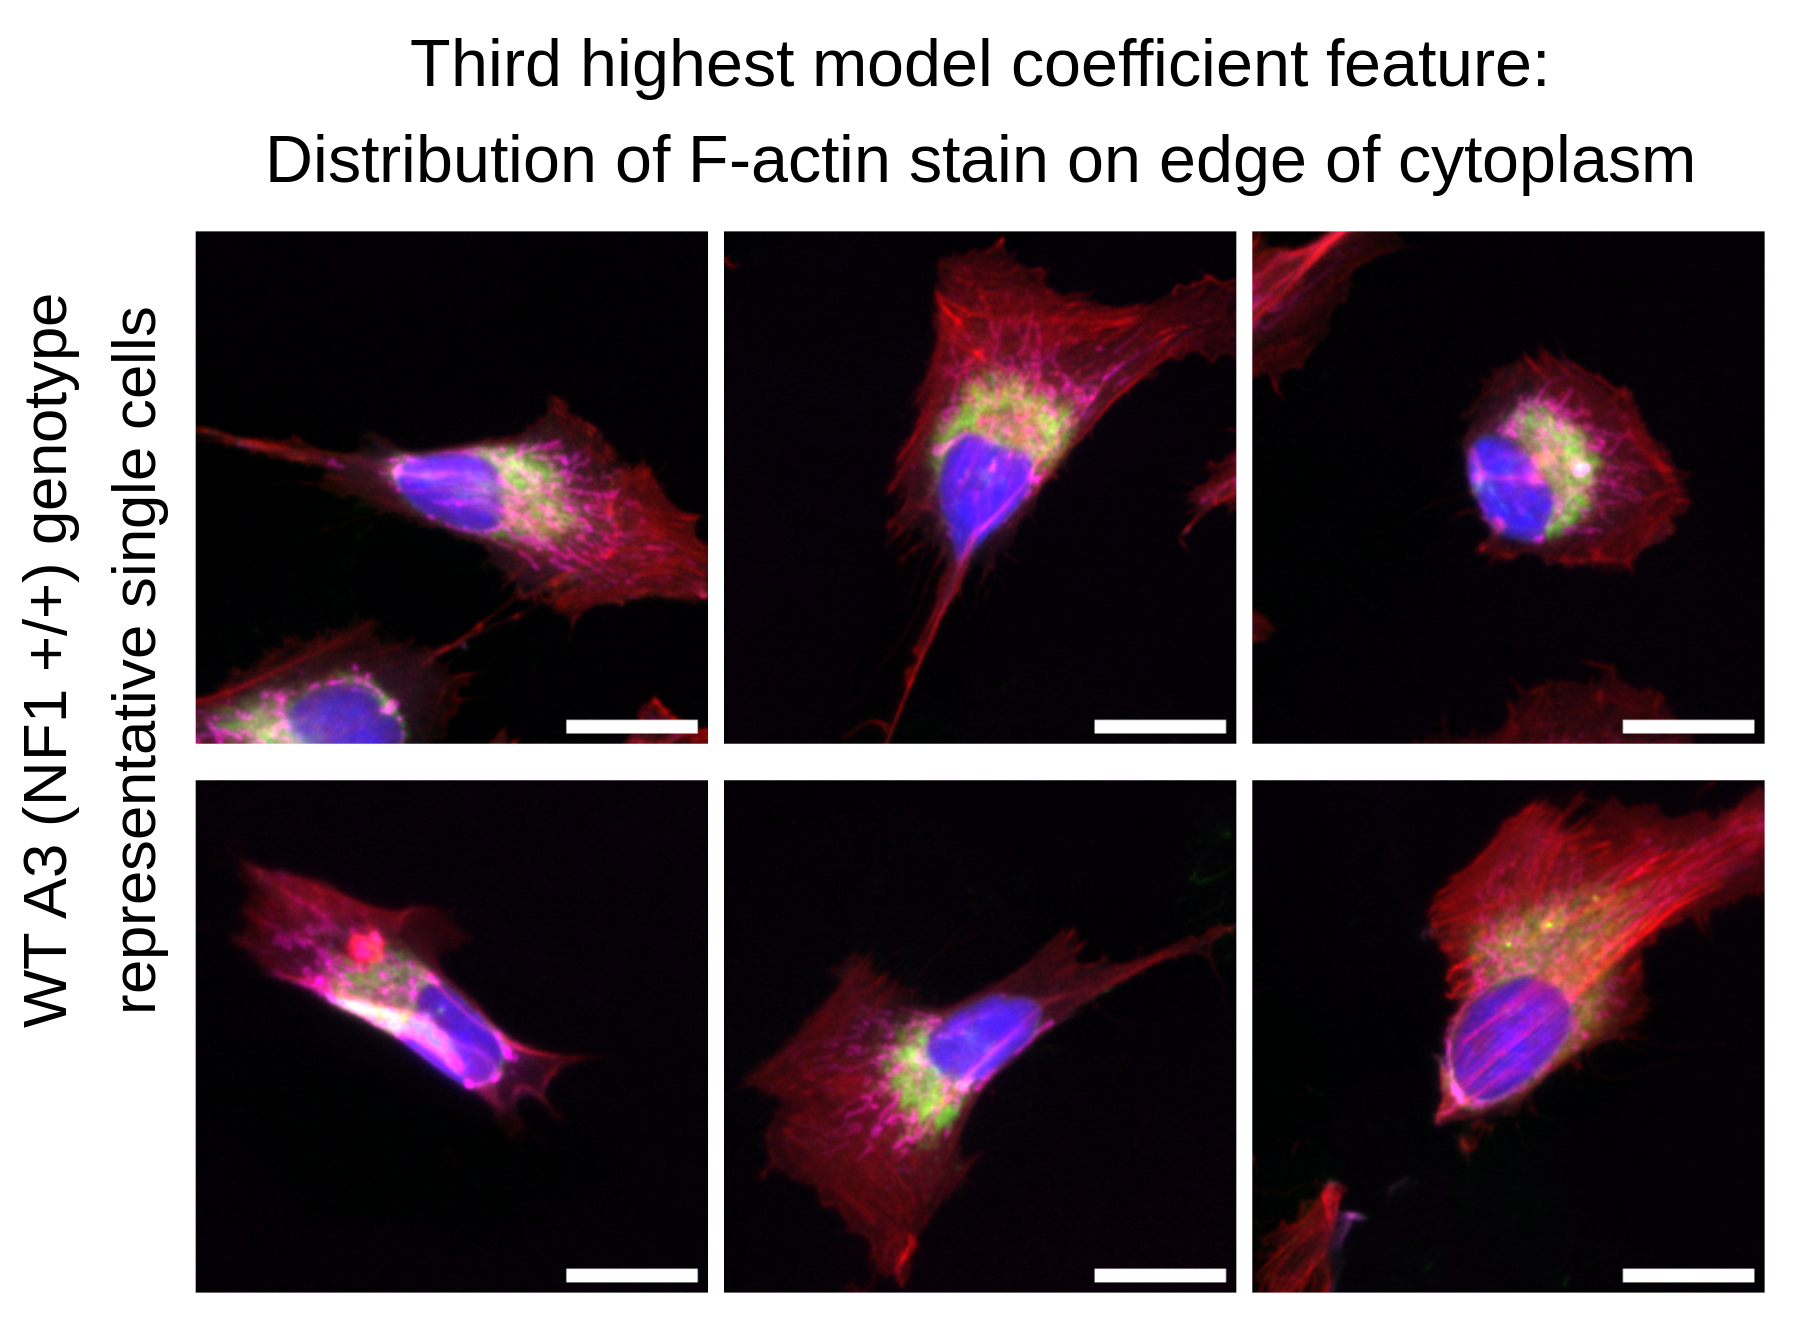

In [8]:
# Create montage
width <- 15
height <- 11

options(repr.plot.width = width, repr.plot.height = height)

top_feat_plot_min <- (
  WT_text + 
  (
    wrap_elements(full = top_patch_text) + 
    wrap_elements(min_top_feat_images_1) + 
    wrap_elements(min_top_feat_images_2) + 
    plot_layout(ncol = 1, heights = c(0.35, 1, 1))
  ) +
  plot_layout(widths = c(0.1, 1)) # Adjusts the width of the left area for the text
)

top_feat_plot_min

# save plot
ggsave(
    file.path(
        paste0(
            "./","cytoplasm_radial_feature_actin_montage_min.png"
        )
    ),
    top_feat_plot_min, width = width, height = height, dpi = 600
)

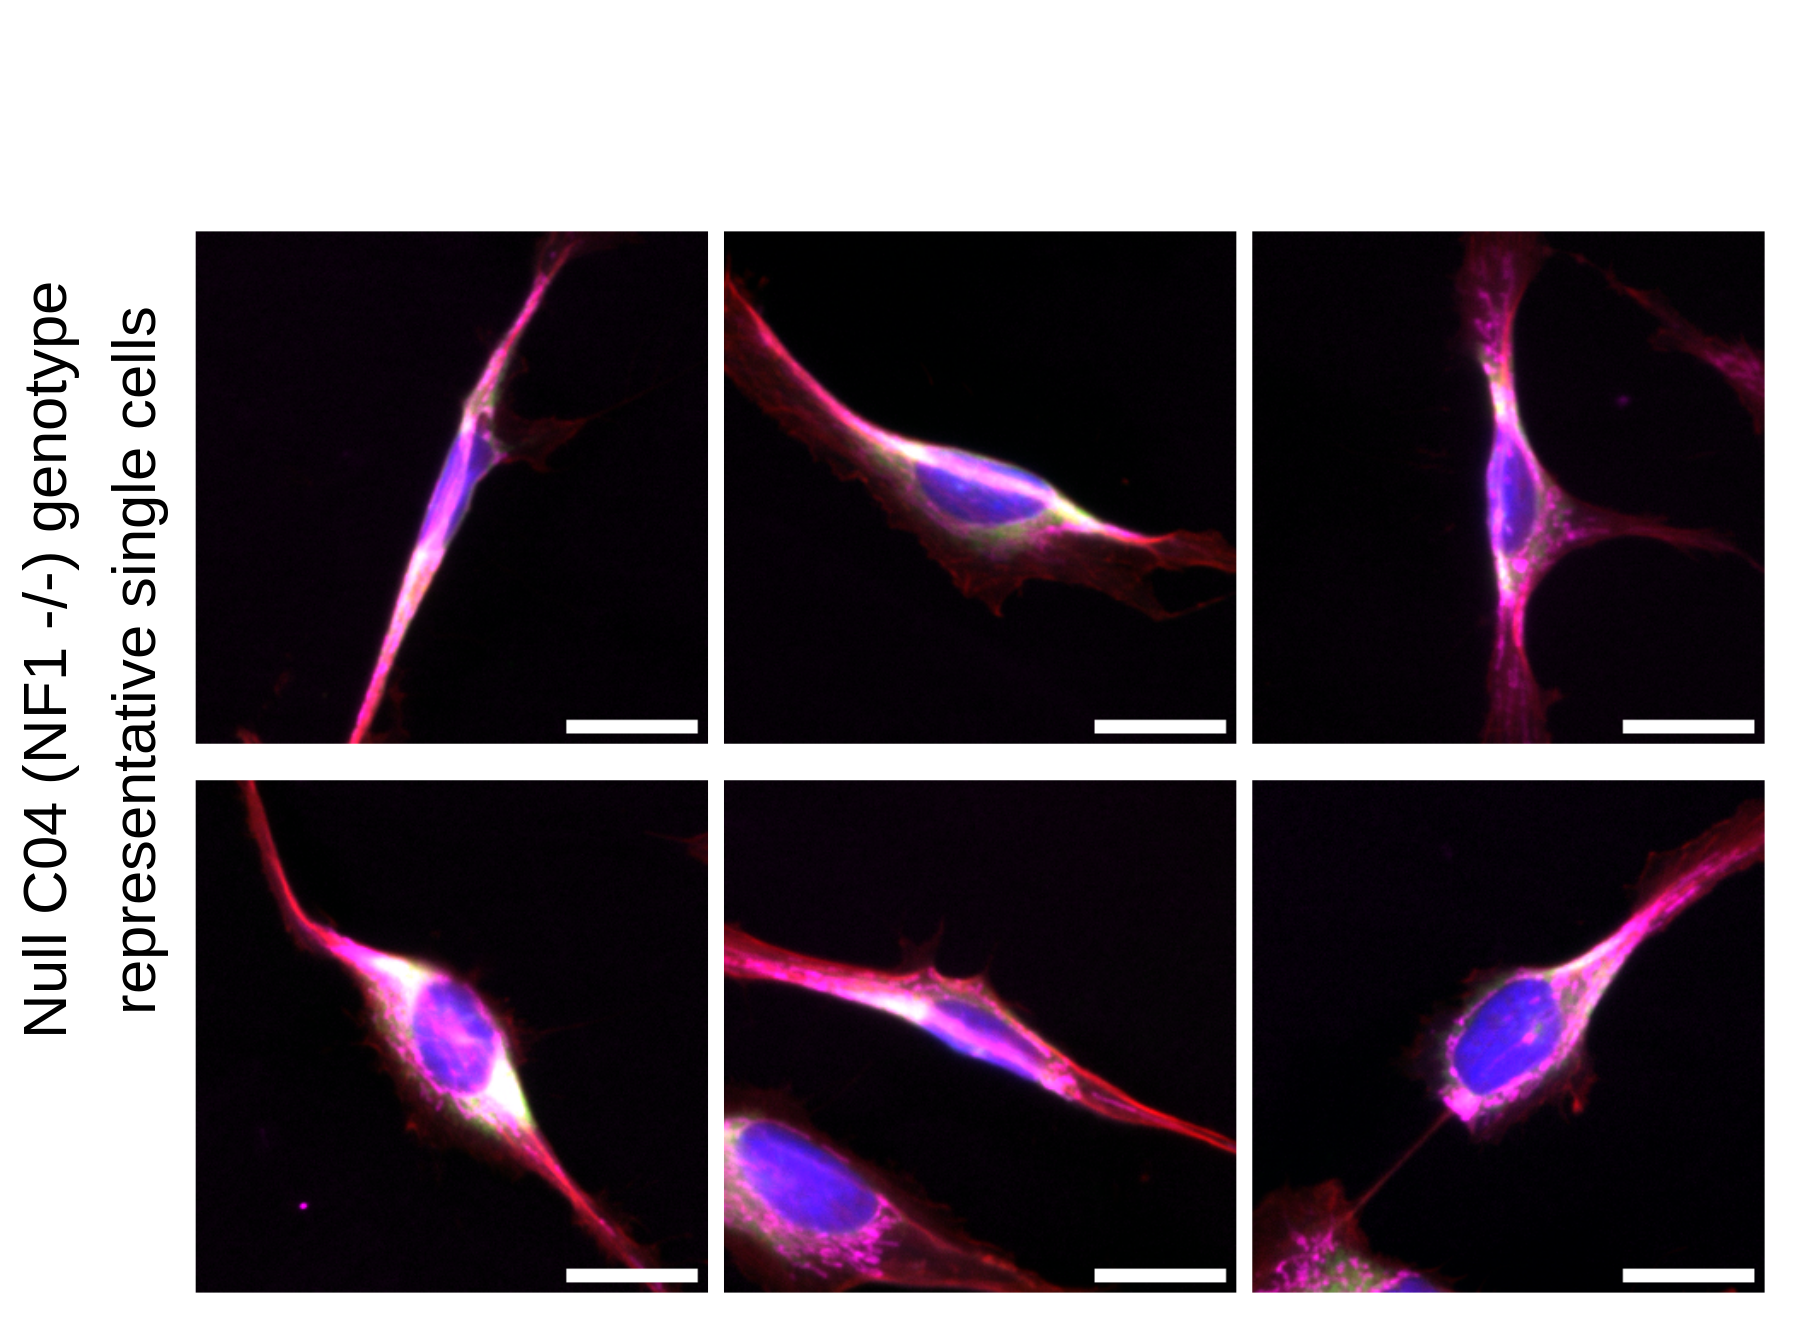

In [9]:
# Create montage
width <- 15
height <- 11

options(repr.plot.width = width, repr.plot.height = height)

# patch the images together
top_feat_plot_max <- (
    Null_text + 
    (
        wrap_elements(full = blank) + 
        wrap_elements(max_top_feat_images_1) + 
        wrap_elements(max_top_feat_images_2) + 
        plot_layout(ncol = 1, heights = c(0.35, 1, 1))
    ) +
    plot_layout(widths = c(0.1, 1)) # Adjusts the width of the left area for the text
)

top_feat_plot_max

# save plot
ggsave(
    file.path(
        paste0(
            "./","cytoplasm_radial_feature_actin_montage_max.png"
        )
    ),
    top_feat_plot_max, width = width, height = height, dpi = 600
)